EXTRAER CARACTERISTICAS DE LAS IMAGENES

In [ ]:
from google.colab import files
import io

In [ ]:
subido = files.upload()
nombre_archivo = next (iter(subido.keys()))

Saving cyberpunk.jpeg to cyberpunk (1).jpeg


In [ ]:
datos = subido[nombre_archivo]

<function matplotlib.pyplot.show(close=None, block=None)>

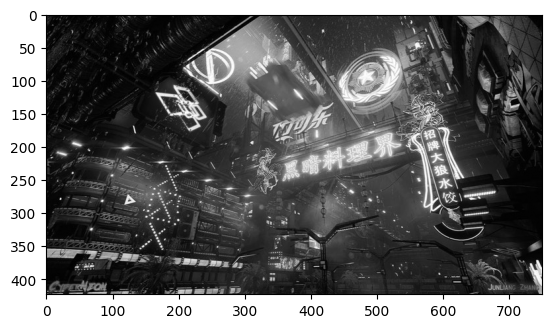

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

arreglo = np.frombuffer(datos, dtype=np.uint8) #lo ntransforma a unidad de 8 bits
img = cv2.imdecode(arreglo, cv2.IMREAD_GRAYSCALE) #leer el arreglo -> imagen

plt.imshow(img, cmap='gray')
plt.show

PATRONES LOCALES BINARIOS

In [ ]:
#LBP
from skimage.feature import local_binary_pattern

def histograma_lbp_por_celdas(img, P=8, R=1, metodo='uniform', cuadricula =(4,4), normalizar = 'True'):
  mapa_lbp = local_binary_pattern(img, P=P, R=R, method=metodo)

  if metodo =='uniform':
    num_bins = P + 2
  elif metodo =='nri_uniform':
    num_bins = P*(P-1) + 3
  else:
    num_bins = 2**P

  alto, ancho = mapa_lbp.shape
  filas, columnas = cuadricula

  if filas > alto or columnas > ancho:
    raise ValueError('La cudaricula es más grande que el tamaño de la imagen')

  indices_y = np.array_split(np.arange(alto), filas)
  indices_x = np.array_split(np.arange(ancho), columnas)

  vectores = []
  for iy in indices_y:
    for ix in indices_x:
      parche = mapa_lbp[np.ix_(iy,ix)]
      hist, _ = np.histogram(parche.ravel(), bins=num_bins, range=(0,num_bins), density=False)
      hist = hist.astype(np.float32)

      if normalizar:
        s = hist.sum()
        if s > 0:
          hist /= s

      vectores.append(hist)

  vector_caracteristicas = np.hstack(vectores).astype(np.float32)
  return vector_caracteristicas, mapa_lbp


In [ ]:
def lbp_multiEscala(img,configuraciones_PR=[(8,1), (16,2)], metodo='uniform', cuadricula =(4,4)):
  #Calcular LBP en 2 escalas para concatenar histogramas en un solo vector

  lista_vectores = []
  lista_mapas = []
  lista_bins = []

  #recorrer cada configuración
  for (P, R) in configuraciones_PR:
    v, mapa = histograma_lbp_por_celdas(img, P=P, R=R, metodo=metodo, cuadricula=cuadricula, normalizar = 'True')
    lista_vectores.append(v) #guardar el vector de escala
    lista_mapas.append(mapa) #guardar el mapa de la escala

    if metodo =='uniform':
      num_bins = P + 2
    elif metodo =='nri_uniform':
      num_bins = P*(P-1) + 3
    else:
      num_bins = 2**P

    lista_bins.append(num_bins)

  vector_total =np.hstack(lista_vectores).astype(np.float32)
  return vector_total, lista_mapas, lista_bins

In [ ]:
#Mostrar cuadricula
from skimage.util import img_as_float

def mostrar_cuadricula(img, cuadricula =(4,4)):
  if img.ndim == 2:
    img_copia = img.copy()
    img = cv2.cvtColor((img_as_float(img)*255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
  else:
    img_copia = img.copy()
    if img_copia.dtype != np.uint8:
      img_copia = (img_as_float(img)*255).astype(np.uint8)

  alto, ancho = img_copia.shape[:2]
  filas, columnas = cuadricula

  for i in range(1,filas):
    y = int(i*alto/filas)
    cv2.line(img_copia, (0,y),(ancho,y),(0,255,255,1)) #linea de grosor 1

  for i in range(1,columnas):
    x = int(i*ancho/columnas)
    cv2.line(img_copia, (x,0),(x,alto),(255,0,0),1) #linea de grosor 1

  img_copia = cv2.cvtColor(img_copia, cv2.COLOR_GRAY2RGB)
  return img_copia

(448,)


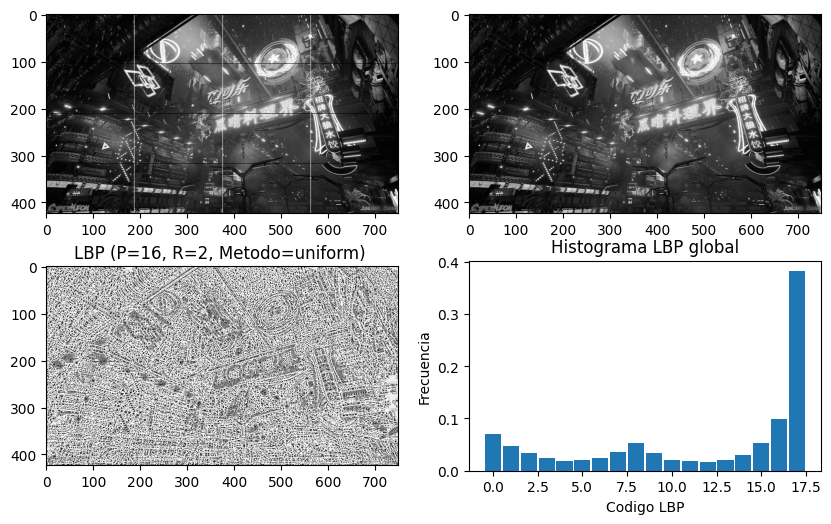

In [ ]:
#PARÁMETROS
configuraciones_PR = [(8,1), (16,2)]
metodo = 'uniform'
cuadricula = (4,4)
imagen=img
vector_caracteristicas, mapa_lbp, lista_num_bins = lbp_multiEscala(imagen, configuraciones_PR, metodo, cuadricula)

print(vector_caracteristicas.shape)

plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
img_cuad= mostrar_cuadricula(imagen, cuadricula=cuadricula)
plt.imshow(img_cuad)

plt.subplot(2,2,2)
plt.imshow(imagen, cmap='gray')

plt.subplot(2,2,3)
P0, R0 = configuraciones_PR[1]
mapa_lbp0 = mapa_lbp[1]
plt.imshow(mapa_lbp0, cmap='gray')
plt.title(f'LBP (P={P0}, R={R0}, Metodo={metodo}) ')

plt.subplot(2,2,4)
if metodo =='uniform':
  num_bins_0 = P0 + 2
else:
  num_bins_0 = 2**P0
hist_global, bordes = np.histogram(mapa_lbp0.ravel(), bins=num_bins_0, range =(0,num_bins_0), density='True')
plt.bar(np.arange(num_bins_0), hist_global, width=0.9)
plt.title('Histograma LBP global')
plt.xlabel('Codigo LBP')
plt.ylabel('Frecuencia')
plt.show()


DESCRIPTORES DE AUIDO E IMAGENES , CADAS UNO EN UN VECTOR (CONCATENAR) Y APLICAR PCA.

OPCION 1: APLICAR PCA POR CADA VECTOR SEPÁRADO Y LUEGO CONCATENAR

OPCION 2: CONCATENAR Y LUEGO APLICAR PCA.

LUEGO USAR KNN PARA QUE CLASIFIQUE CON DIFERENTES VALORES DE K Y HACER EVALUACION DE CON CUAL 'K' HACE MEJOR CLASIFICACIÓN

70% entreno
30% prueba



#####################

PCA y KNN

In [ ]:
!pip install scikit-image

In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#suponer que X es la matriz de caracteristicas (numero de ejemplos o instancias x numero de caracteristicas)

#Escalamiento
escalado = StandardScaler() #llamar a una isntancia
X_escalado = escalado.fit_transform(X)

#Reduccion dimensionalidad con PCA
pca = PCA(n_components=0.97) #significa que conserva el 97% de la varianza total (no usar n_componentes)
X_pca = pca.fit_transform(X_escalado)

print(f'Tamaño despues de PCA:',{X_pca.shape})
#X_pca 500x150

#Graficar la proporcion de VARIANZA explicada por cada componente
var_explicada = pca.explained_variance_
var_explicada_acum = var_explicada.sum()

plt.figure(figsize=(10,4))
plt.plot(range(1, len(var_explicada_acum)+1),var_explicada_acum, marker='o')
plt.xlabel('Numero Componentes principales')
plt.ylabel('Varianza explicada Acumulada')
plt.grid()
plt.show

In [ ]:
#Division de los datos
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X_pca,
    y(etiquetas), #Vector de etiquetas
    text_size=0.3,
    random_state=42, #semilla para reproducibilidad
    stratify=y #estratificación
    )

In [ ]:
#Clasificación KNN
knn = KNeighborsClassifier()

knn.fit(X_entrenamiento, y_entrenamiento) #Solo entrena con los datos de entrenamiento

In [ ]:
#Evaluacion
y_pred = knn.predict(y_prueba)

exactitud = accuracy_score(y_prueba, y_pred) #buen valor > 0.7
report = classification_report(y_prueba, y_pred) #entrega precision, recall, f1_score --> metricas que mide que tan bien esta clasificando

#Dibujar matriz de confunsion
matriz_confusion = confusion_matrix(y_prueba, y_pred)

#consultar en la biblioteca

import seaborn as sns
#Dibujar mapa de calor

DESCRIPTORES QUE PODEMOS REVISAR

LBP
MCO
HOG